In [1]:
pip install torch torchvision --index-url https://download.pytorch.org/whl/cu124

Looking in indexes: https://download.pytorch.org/whl/cu124
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install diffusers transformers accelerate matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import os
import warnings
import torch
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline

In [4]:
warnings.filterwarnings("ignore")

In [5]:
MODEL_ID = "runwayml/stable-diffusion-v1-5"
NEG_PROMPT_DEFAULT = "blurry, low quality, distorted, ugly, deformed"
OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [6]:
def verificar_dispositivo():
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"✅ Dispositivo: {device.upper()}")
    if device == "cuda":
        print(f"   GPU : {torch.cuda.get_device_name(0)}")
        print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    else:
        print("⚠️  Sin GPU — la generación será lenta.")
    return device

In [7]:
def cargar_modelo(device):
    dtype = torch.float32 if device != "cuda" else torch.float16
    print(f"\n📥 Cargando modelo: {MODEL_ID} ...")
    pipe = StableDiffusionPipeline.from_pretrained(MODEL_ID, torch_dtype=dtype).to(device)
    
    pipe.safety_checker = None
    pipe.feature_extractor = None
    
    pipe.enable_attention_slicing()
    print("✅ Modelo listo.\n")
    return pipe

In [8]:
def generar_imagen(
    pipe,
    device,
    prompt,
    negative_prompt=NEG_PROMPT_DEFAULT,
    steps=30,
    guidance=7.5,
    height=512,
    width=512,
    seed=42,
    guardar_como=None,
    mostrar=True,
):
    generator = torch.Generator(device=device).manual_seed(seed)
    print(f"🎨 Generando: {prompt[:70]}{'...' if len(prompt) > 70 else ''}")

    result = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=steps,
        guidance_scale=guidance,
        height=height,
        width=width,
        generator=generator,
    )
    imagen = result.images[0]

    if guardar_como:
        ruta = os.path.join(OUTPUT_DIR, guardar_como)
        imagen.save(ruta)
        print(f"   💾 Guardada: {ruta}")

    if mostrar:
        plt.figure(figsize=(5, 5))
        plt.imshow(imagen)
        plt.axis("off")
        plt.title(prompt[:60] + ("..." if len(prompt) > 60 else ""), fontsize=8)
        plt.tight_layout()
        plt.show()

    return imagen


In [9]:
def guardar_grilla(imagenes, titulos, nombre_archivo, titulo_figura=""):
    n = len(imagenes)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))
    if titulo_figura:
        fig.suptitle(titulo_figura, fontsize=13, fontweight="bold")

    axs = axes.flatten() if hasattr(axes, "flatten") else [axes]
    for ax, img, titulo in zip(axs, imagenes, titulos):
        ax.imshow(img)
        ax.set_title(titulo, fontsize=9)
        ax.axis("off")
    for ax in axs[n:]:
        ax.set_visible(False)

    plt.tight_layout()
    ruta = os.path.join(OUTPUT_DIR, nombre_archivo)
    plt.savefig(ruta, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"   💾 Grilla guardada: {ruta}")

In [10]:
def actividad_primera_generacion(pipe, device):
    print("\n" + "=" * 60)
    print("ACTIVIDAD 3 — Primera generación")
    print("=" * 60)
    generar_imagen(
        pipe, device,
        prompt="A surreal futuristic city in the clouds, digital art, highly detailed",
        steps=30,
        guidance=7.5,
        seed=42,
        guardar_como="act3_ciudad.png",
    )

In [11]:
def actividad_explorar_parametros(pipe, device):
    print("\n" + "=" * 60)
    print("ACTIVIDAD 4 — Explorar parámetros")
    print("=" * 60)

    # -- Experimento 1: num_inference_steps --
    print("\n→ Experimento 1: num_inference_steps")
    prompt = "A majestic lion in a savanna at sunset, photorealistic"
    steps_list = [10, 25, 50]
    imgs, titulos = [], []
    for s in steps_list:
        print(f"   steps={s}")
        imgs.append(generar_imagen(pipe, device, prompt, steps=s, seed=42, mostrar=False))
        titulos.append(f"steps = {s}")
    guardar_grilla(imgs, titulos, "act4_steps.png", "Efecto de num_inference_steps")

    # -- Experimento 2: guidance_scale --
    print("\n→ Experimento 2: guidance_scale")
    prompt = "An enchanted forest with glowing mushrooms, fantasy art"
    guidance_list = [3.0, 7.5, 15.0]
    imgs, titulos = [], []
    for g in guidance_list:
        print(f"   guidance={g}")
        imgs.append(generar_imagen(pipe, device, prompt, guidance=g, seed=42, mostrar=False))
        titulos.append(f"guidance = {g}")
    guardar_grilla(imgs, titulos, "act4_guidance.png", "Efecto de guidance_scale")

    # -- Experimento 3: seed --
    print("\n→ Experimento 3: seed")
    prompt = "A cozy cabin in the mountains during winter, snow falling"
    seeds = [0, 1234, 9999]
    imgs, titulos = [], []
    for s in seeds:
        print(f"   seed={s}")
        imgs.append(generar_imagen(pipe, device, prompt, seed=s, mostrar=False))
        titulos.append(f"seed = {s}")
    guardar_grilla(imgs, titulos, "act4_seeds.png", "Efecto del seed")


In [12]:
def actividad_estilos(pipe, device):
    print("\n" + "=" * 60)
    print("ACTIVIDAD 5 — Estilos artísticos")
    print("=" * 60)

    escena = "a woman standing in a garden with flowers"
    estilos = {
        "Oil Painting":    f"{escena}, oil painting, impressionist, thick brushstrokes, Monet style",
        "Cyberpunk":       f"{escena}, cyberpunk, neon lights, futuristic, dark atmosphere, blade runner",
        "Photorealistic":  f"{escena}, photorealistic, 8k, DSLR photo, natural lighting, sharp focus",
        "Watercolor":      f"{escena}, watercolor illustration, soft colors, delicate, artistic",
    }
    neg = "blurry, low quality, distorted, deformed, ugly, bad anatomy"

    imgs, titulos = [], []
    for nombre, prompt in estilos.items():
        print(f"   Estilo: {nombre}")
        img = generar_imagen(pipe, device, prompt, negative_prompt=neg, seed=42, mostrar=False)
        img.save(os.path.join(OUTPUT_DIR, f"act5_estilo_{nombre.lower().replace(' ', '_')}.png"))
        imgs.append(img)
        titulos.append(nombre)

    guardar_grilla(imgs, titulos, "act5_estilos.png", "Comparación de estilos artísticos")

In [13]:
def actividad_negative_prompt(pipe, device):
    print("\n" + "=" * 60)
    print("ACTIVIDAD 6 — Prompts negativos")
    print("=" * 60)

    prompt = "a portrait of a person smiling, professional photography"
    configs = [
        {"titulo": "Sin negative prompt", "neg": ""},
        {"titulo": "Con negative prompt",
         "neg": "blurry, distorted face, extra fingers, bad anatomy, low quality, artifacts, ugly"},
    ]
    imgs, titulos = [], []
    for cfg in configs:
        print(f"   {cfg['titulo']}")
        imgs.append(generar_imagen(pipe, device, prompt, negative_prompt=cfg["neg"],
                                   seed=42, mostrar=False))
        titulos.append(cfg["titulo"])

    guardar_grilla(imgs, titulos, "act6_negative_prompt.png", "Efecto del Negative Prompt")

In [14]:
def actividad_lotes(pipe, device):
    print("\n" + "=" * 60)
    print("ACTIVIDAD 7 (Bonus) — Generación por lotes")
    print("=" * 60)

    prompts = [
        "A dragon flying over a medieval castle at night, fantasy art, epic",
        "An astronaut exploring an alien coral reef, underwater, surreal",
        "A steampunk clockwork market with floating airships, detailed, colorful",
        "Ancient Japanese temple in autumn, cherry blossoms, fog, watercolor",
        "A robot chef cooking in a futuristic kitchen, isometric, cartoon style",
        "Deep ocean bioluminescent creatures, cinematic, dark blue atmosphere",
    ]
    neg = "blurry, low quality, ugly, deformed, watermark, text"

    imgs, titulos = [], []
    for i, prompt in enumerate(prompts):
        print(f"   [{i+1}/{len(prompts)}] {prompt[:55]}...")
        img = generar_imagen(pipe, device, prompt, negative_prompt=neg,
                             steps=25, seed=i * 100, mostrar=False,
                             guardar_como=f"act7_lote_{i+1:02d}.png")
        imgs.append(img)
        titulos.append(f"{i+1}. {prompt[:40]}...")

    guardar_grilla(imgs, titulos, "act7_galeria_lote.png", "Galería — Generación por Lotes")


In [15]:
def actividad_prompt_engineering(pipe, device):
    print("\n" + "=" * 60)
    print("ACTIVIDAD 8 (Bonus) — Prompt Engineering")
    print("=" * 60)

    configs = [
        {
            "titulo": "Prompt simple",
            "prompt": "a cat",
            "neg": "",
        },
        {
            "titulo": "Prompt elaborado",
            "prompt": (
                "a majestic tabby cat sitting on a velvet throne, "
                "royal portrait, dramatic renaissance lighting, "
                "oil painting style, ultra detailed, rich jewel tones, 8k resolution"
            ),
            "neg": "blurry, low quality, cartoon, deformed, ugly",
        },
    ]

    imgs, titulos = [], []
    for cfg in configs:
        print(f"   {cfg['titulo']}: {cfg['prompt'][:55]}...")
        img = generar_imagen(pipe, device, cfg["prompt"], negative_prompt=cfg["neg"],
                             steps=30, seed=42, mostrar=False)
        img.save(os.path.join(OUTPUT_DIR, f"act8_{cfg['titulo'].split()[1].lower()}.png"))
        imgs.append(img)
        titulos.append(cfg["titulo"])

    guardar_grilla(imgs, titulos, "act8_prompt_engineering.png",
                   "Prompt Engineering: Simple vs. Elaborado")


In [16]:
def sandbox(pipe, device):
    print("\n" + "=" * 60)
    print("SANDBOX — Zona de experimentación libre")
    print("=" * 60)

    # ── Edita estos valores ──────────────────────────────────────────────────
    MI_PROMPT          = "A Viking warrior in a cinematic battle scene, epic fantasy, dramatic lighting"
    MI_NEGATIVE_PROMPT = "blurry, low quality, cartoon, deformed"
    MI_STEPS           = 35
    MI_GUIDANCE        = 8.0
    MI_SEED            = 777
    MI_HEIGHT          = 512
    MI_WIDTH           = 512
    # ────────────────────────────────────────────────────────────────────────

    generar_imagen(
        pipe, device,
        prompt=MI_PROMPT,
        negative_prompt=MI_NEGATIVE_PROMPT,
        steps=MI_STEPS,
        guidance=MI_GUIDANCE,
        height=MI_HEIGHT,
        width=MI_WIDTH,
        seed=MI_SEED,
        guardar_como="sandbox_mi_imagen.png",
    )

In [17]:
def resumen_archivos():
    print("\n" + "=" * 60)
    print("📁 Archivos generados en la carpeta 'outputs/'")
    print("=" * 60)
    archivos = sorted(f for f in os.listdir(OUTPUT_DIR) if f.endswith(".png"))
    for f in archivos:
        kb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) / 1024
        print(f"   {f:<50} ({kb:.1f} KB)")
    print(f"\n✅ Total: {len(archivos)} archivo(s)")

✅ Dispositivo: CUDA
   GPU : NVIDIA GeForce GTX 1660 SUPER
   VRAM: 6.44 GB

📥 Cargando modelo: runwayml/stable-diffusion-v1-5 ...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


✅ Modelo listo.


ACTIVIDAD 3 — Primera generación
🎨 Generando: A surreal futuristic city in the clouds, digital art, highly detailed


  0%|          | 0/30 [00:00<?, ?it/s]

   💾 Guardada: outputs\act3_ciudad.png


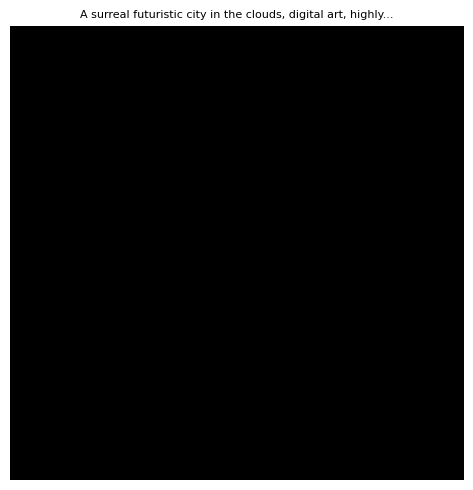


ACTIVIDAD 4 — Explorar parámetros

→ Experimento 1: num_inference_steps
   steps=10
🎨 Generando: A majestic lion in a savanna at sunset, photorealistic


  0%|          | 0/10 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [18]:
if __name__ == "__main__":
    device = verificar_dispositivo()
    pipe   = cargar_modelo(device)

    actividad_primera_generacion(pipe, device)
    actividad_explorar_parametros(pipe, device)
    actividad_estilos(pipe, device)
    actividad_negative_prompt(pipe, device)
    actividad_lotes(pipe, device)
    actividad_prompt_engineering(pipe, device)
    sandbox(pipe, device)
    resumen_archivos()